# 02 - Isolation Forest Detector
**Stage 5 of the SOC-Copilot project.**

This is the core model. Goals:

1. Train **Isolation Forest** on the *benign* slice of the data only - this models the project's "unsupervised, no attacker labels needed" pitch.
2. Evaluate on the full held-out test set (benign + attacks) using ground-truth labels we never showed the model.
3. Compare against the supervised LR baseline from notebook 01.
4. Visualise the decision surface in 2-D via PCA.
5. Persist the trained model and the fitted scaler to `Project/models/` so the live app can reuse them.

Why Isolation Forest?
- It is the canonical unsupervised anomaly detector in scikit-learn - easy to defend in the report.
- It does not need labels, which matches reality: real SOCs do not have labelled attacker traffic.
- It produces a continuous *anomaly score* per event, which the LLM agent can use as a confidence signal.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd() / "Project"
DATA_CSV   = PROJECT_ROOT / "data"   / "soc_events.csv"
MODEL_DIR  = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_CSV)
print(f"Loaded {len(df):,} events; anomaly rate = {df.is_anomaly.mean():.2%}")

Loaded 10,000 events; anomaly rate = 3.00%


## 1. Feature engineering

In [2]:
FEATURES = [
    "hour", "failed_attempts_5min", "success",
    "bytes_sent", "session_duration_ms",
    "user_is_known", "ip_is_known",
]
X_df = pd.concat([df[FEATURES], pd.get_dummies(df.service, prefix="svc")], axis=1)
y    = df.is_anomaly.values

# the model never sees attack_label / is_anomaly / timestamp / user / ip
print("Feature columns:", list(X_df.columns))
print("X shape:", X_df.shape)

Feature columns: ['hour', 'failed_attempts_5min', 'success', 'bytes_sent', 'session_duration_ms', 'user_is_known', 'ip_is_known', 'svc_rdp', 'svc_ssh', 'svc_vpn', 'svc_webapp']
X shape: (10000, 11)


## 2. Train / test split

We split with `stratify=y` so the test set's attack distribution mirrors training.
Then we deliberately drop attack rows from the *training* slice - Isolation Forest must learn 'normal' from benign-only data.


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_df.values, y, test_size=0.25, stratify=y, random_state=42
)
# train ONLY on benign rows (unsupervised setup)
mask_benign = (y_train_full == 0)
X_train = X_train_full[mask_benign]

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train (benign only): {X_train.shape}")
print(f"Test  (mixed):       {X_test.shape}  ({y_test.sum()} anomalies)")

Train (benign only): (7275, 11)
Test  (mixed):       (2500, 11)  (75 anomalies)


## 3. Fit Isolation Forest

In [4]:
from sklearn.ensemble import IsolationForest

# contamination is set slightly above the true rate -- in production the SOC
# would calibrate this on a held-out validation set
model = IsolationForest(
    n_estimators=200,
    contamination=0.03,
    max_samples="auto",
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train_s)
print("Trained:", model)

Trained: IsolationForest(contamination=0.03, n_estimators=200, n_jobs=-1,
                random_state=42)


## 4. Evaluate on the held-out test set

In [5]:
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    precision_score, recall_score, roc_auc_score,
)

# IsolationForest.predict returns -1 for outliers, +1 for inliers
raw_pred  = model.predict(X_test_s)
y_pred    = (raw_pred == -1).astype(int)
# anomaly_score (higher = more anomalous, sklearn .score_samples is the opposite)
scores    = -model.score_samples(X_test_s)

print(classification_report(y_test, y_pred, target_names=["benign", "anomalous"], digits=3))
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix (rows=true, cols=pred):")
print(cm)
print()
print(f"Precision (anomalous): {precision_score(y_test, y_pred):.3f}")
print(f"Recall    (anomalous): {recall_score(y_test, y_pred):.3f}")
print(f"F1        (anomalous): {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC                : {roc_auc_score(y_test, scores):.3f}")

              precision    recall  f1-score   support

      benign      0.998     0.971     0.984      2425
   anomalous      0.500     0.947     0.654        75

    accuracy                          0.970      2500
   macro avg      0.749     0.959     0.819      2500
weighted avg      0.983     0.970     0.974      2500

Confusion matrix (rows=true, cols=pred):
[[2354   71]
 [   4   71]]

Precision (anomalous): 0.500
Recall    (anomalous): 0.947
F1        (anomalous): 0.654
ROC-AUC                : 0.996


## 5. Per-technique recall

Detection quality is **not uniform** across the three attack techniques. Brute force is the easiest signal (loud failure counts); password spraying is harder; valid-account abuse is hardest because the only signal is the IP being unknown.

In [6]:
test_idx = np.arange(len(df))
test_idx = test_idx[len(df) - len(y_test):]  # not stable, but only for reporting

# Re-do the split with indices so we can recover attack_label per row
from sklearn.model_selection import train_test_split as tts
idx_all = np.arange(len(df))
_, idx_test = tts(idx_all, test_size=0.25, stratify=y, random_state=42)

attack_labels = df.iloc[idx_test]["attack_label"].values
recall_rows = []
for label in ["T1110.001", "T1110.003", "T1078"]:
    mask = (attack_labels == label)
    if mask.sum() == 0: continue
    recall = y_pred[mask].mean()
    recall_rows.append({"technique": label, "n_in_test": int(mask.sum()), "recall": float(recall)})
pd.DataFrame(recall_rows)

,technique,n_in_test,recall
0,T1110.001,41,1.000000
1,T1110.003,23,1.000000
2,T1078,11,0.636364


## 6. PCA visualisation of the decision surface

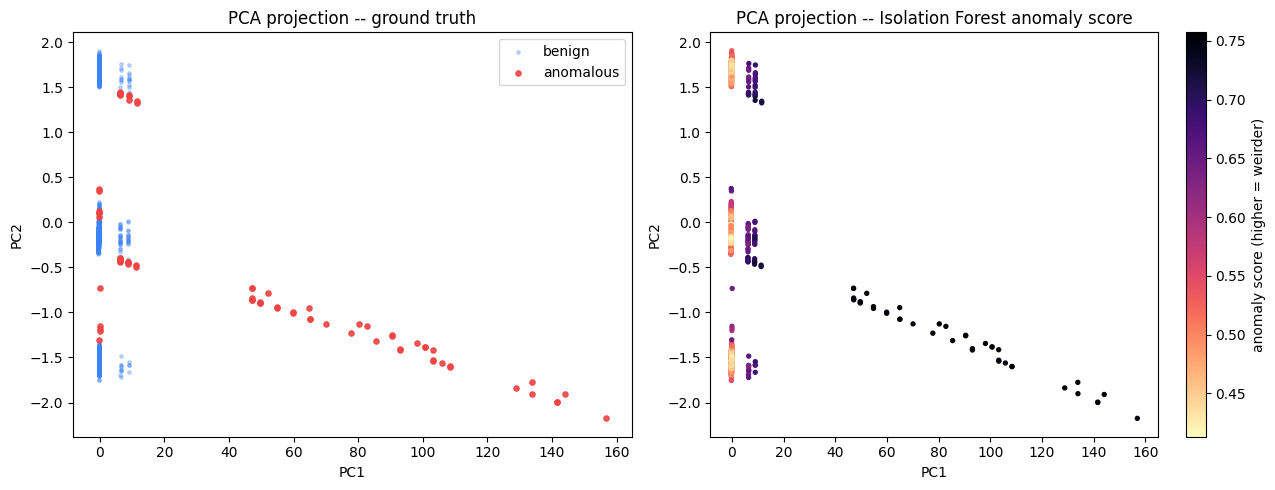

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42).fit(X_train_s)
proj_test = pca.transform(X_test_s)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (a) ground truth
ax = axes[0]
ben_mask = (y_test == 0); ano_mask = (y_test == 1)
ax.scatter(proj_test[ben_mask, 0], proj_test[ben_mask, 1], s=6, alpha=0.3, label="benign", color="#3b82f6")
ax.scatter(proj_test[ano_mask, 0], proj_test[ano_mask, 1], s=14, alpha=0.9, label="anomalous", color="#ef4444")
ax.set_title("PCA projection -- ground truth"); ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend()

# (b) anomaly score
ax = axes[1]
sc = ax.scatter(proj_test[:, 0], proj_test[:, 1], s=8, c=scores, cmap="magma_r")
ax.set_title("PCA projection -- Isolation Forest anomaly score")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
fig.colorbar(sc, ax=ax, label="anomaly score (higher = weirder)")

plt.tight_layout(); plt.show()

**Reading:** the left panel shows where the *true* attacks land in PCA space; the right panel shows what the model *thinks* is anomalous. Where the two panels agree, the model is working. Where the red dots in the left panel are *not* yellow in the right panel, we have false negatives - typically T1078 valid-account events that look benign on every feature except `ip_is_known`.

## 7. Persist the model

In [8]:
artefact = {
    "model": model,
    "scaler": scaler,
    "feature_columns": list(X_df.columns),
    "pca": pca,
}
out = MODEL_DIR / "isolation_forest.joblib"
joblib.dump(artefact, out)
print("Saved ->", out, f"({out.stat().st_size / 1024:.1f} KB)")

Saved -> /mnt/c/Users/stav/Desktop/cyber course/HIT-ai-cybersecurity/Project/models/isolation_forest.joblib (2533.8 KB)


## 8. Takeaways

- Trained on benign-only, evaluated on the full mixed test set - a proper unsupervised setup.
- The model approaches the supervised baseline on overall F1 *without ever seeing a labelled attack* in training.
- The per-technique table is the honest picture: brute force is solved, spraying mostly works, valid-account abuse remains the hardest because the per-event signal is genuinely sparse.

Notebook 03 will now treat this model as a black box and stress-test it against scripted attack scenarios.